In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_style("darkgrid")
plt.rcParams["figure.figsize"] = (12, 5)

print("All imports successful!")

All imports successful!


In [6]:
# TMDB datasets
movies_tmdb = pd.read_csv("../data/raw/tmdb_5000_movies.csv")
credits = pd.read_csv("../data/raw/tmdb_5000_credits.csv")

# MovieLens datasets
movies_ml = pd.read_csv("../data/raw/movies.csv")
ratings = pd.read_csv("../data/raw/ratings.csv")
links = pd.read_csv("../data/raw/links.csv")

print("TMDB movies:", movies_tmdb.shape)
print("Credits:", credits.shape)
print("MovieLens movies:", movies_ml.shape)
print("Ratings:", ratings.shape)
print("Links:", links.shape)

TMDB movies: (4803, 20)
Credits: (4803, 4)
MovieLens movies: (62423, 3)
Ratings: (25000095, 4)
Links: (62423, 3)


In [9]:
movies_tmdb.head(2)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500


In [11]:
print("TMDB movies columns:", movies_tmdb.columns.tolist())
print()
print("Credits columns:", credits.columns.tolist())
print()
print("MovieLens movies columns:", movies_ml.columns.tolist())
print()
print("Ratings columns:", ratings.columns.tolist())
print()
print("Links columns:", links.columns.tolist())

TMDB movies columns: ['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'vote_average', 'vote_count']

Credits columns: ['movie_id', 'title', 'cast', 'crew']

MovieLens movies columns: ['movieId', 'title', 'genres']

Ratings columns: ['userId', 'movieId', 'rating', 'timestamp']

Links columns: ['movieId', 'imdbId', 'tmdbId']


In [13]:
print("=== TMDB Movies nulls ===")
print(movies_tmdb.isnull().sum())
print()
print("=== Credits nulls ===")
print(credits.isnull().sum())

=== TMDB Movies nulls ===
budget                     0
genres                     0
homepage                3091
id                         0
keywords                   0
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  844
title                      0
vote_average               0
vote_count                 0
dtype: int64

=== Credits nulls ===
movie_id    0
title       0
cast        0
crew        0
dtype: int64


In [15]:
print("=== Ratings sample ===")
print(ratings.head(3))
print()
print("=== Links sample ===")
print(links.head(3))
print()
print("=== MovieLens movies sample ===")
print(movies_ml.head(3))

=== Ratings sample ===
   userId  movieId  rating   timestamp
0       1      296     5.0  1147880044
1       1      306     3.5  1147868817
2       1      307     5.0  1147868828

=== Links sample ===
   movieId  imdbId   tmdbId
0        1  114709    862.0
1        2  113497   8844.0
2        3  113228  15602.0

=== MovieLens movies sample ===
   movieId                    title  \
0        1         Toy Story (1995)   
1        2           Jumanji (1995)   
2        3  Grumpier Old Men (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  


In [17]:
# Keep only useful columns from TMDB
movies_tmdb = movies_tmdb[['id', 'title', 'genres', 'keywords', 
                             'overview', 'vote_average', 'vote_count',
                             'release_date', 'runtime']]

print("Shape after column drop:", movies_tmdb.shape)
movies_tmdb.head(2)

Shape after column drop: (4803, 9)


,id,title,genres,keywords,overview,vote_average,vote_count,release_date,runtime
0,19995,Avatar,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...","In the 22nd century, a paraplegic Marine is di...",7.2,11800,2009-12-10,162.0
1,285,Pirates of the Caribbean: At World's End,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...","Captain Barbossa, long believed to be dead, ha...",6.9,4500,2007-05-19,169.0


In [19]:
import ast

# look at one row of cast and crew raw data
print("=== RAW CAST (first movie) ===")
print(credits['cast'][0][:500])  # first 500 chars so it doesnt flood
print()
print("=== RAW CREW (first movie) ===")
print(credits['crew'][0][:500])

=== RAW CAST (first movie) ===
[{"cast_id": 242, "character": "Jake Sully", "credit_id": "5602a8a7c3a3685532001c9a", "gender": 2, "id": 65731, "name": "Sam Worthington", "order": 0}, {"cast_id": 3, "character": "Neytiri", "credit_id": "52fe48009251416c750ac9cb", "gender": 1, "id": 8691, "name": "Zoe Saldana", "order": 1}, {"cast_id": 25, "character": "Dr. Grace Augustine", "credit_id": "52fe48009251416c750aca39", "gender": 1, "id": 10205, "name": "Sigourney Weaver", "order": 2}, {"cast_id": 4, "character": "Col. Quaritch", "c

=== RAW CREW (first movie) ===
[{"credit_id": "52fe48009251416c750aca23", "department": "Editing", "gender": 0, "id": 1721, "job": "Editor", "name": "Stephen E. Rivkin"}, {"credit_id": "539c47ecc3a36810e3001f87", "department": "Art", "gender": 2, "id": 496, "job": "Production Design", "name": "Rick Carter"}, {"credit_id": "54491c89c3a3680fb4001cf7", "department": "Sound", "gender": 0, "id": 900, "job": "Sound Designer", "name": "Christopher Boyes"}, {"credit_id":

In [31]:
import ast

def get_top_cast(cast_str):
    try:
        cast_list = ast.literal_eval(cast_str)
        # grab name of first 3 actors only
        return [person['name'] for person in cast_list if person['order'] < 3]
    except:
        return []

def get_director(crew_str):
    try:
        crew_list = ast.literal_eval(crew_str)
        # find the person whose job is Director
        for person in crew_list:
            if person['job'] == 'Director':
                return person['name']
    except:
        pass
    return None

# test on first row before applying to whole dataset
print("Top cast:", get_top_cast(credits['cast'][0]))
print("Director:", get_director(credits['crew'][0]))

KeyError: 'cast'

In [33]:
# reload credits fresh
credits = pd.read_csv("../data/raw/tmdb_5000_credits.csv")

# apply both functions
credits['top_cast'] = credits['cast'].apply(get_top_cast)
credits['director'] = credits['crew'].apply(get_director)

# drop raw columns
credits = credits[['movie_id', 'title', 'top_cast', 'director']]

print("Credits shape:", credits.shape)
credits.head(3)

Credits shape: (4803, 4)


,movie_id,title,top_cast,director
0,19995,Avatar,"[Sam Worthington, Zoe Saldana, Sigourney Weaver]",James Cameron
1,285,Pirates of the Caribbean: At World's End,"[Johnny Depp, Orlando Bloom, Keira Knightley]",Gore Verbinski
2,206647,Spectre,"[Daniel Craig, Christoph Waltz, Léa Seydoux]",Sam Mendes


In [35]:
def parse_names(obj_str):
    try:
        obj_list = ast.literal_eval(obj_str)
        return [item['name'] for item in obj_list]
    except:
        return []

movies_tmdb['genres'] = movies_tmdb['genres'].apply(parse_names)
movies_tmdb['keywords'] = movies_tmdb['keywords'].apply(parse_names)

# verify it worked
print("Genres example:", movies_tmdb['genres'][0])
print("Keywords example:", movies_tmdb['keywords'][0][:5])  # first 5 keywords only

Genres example: ['Action', 'Adventure', 'Fantasy', 'Science Fiction']
Keywords example: ['culture clash', 'future', 'space war', 'space colony', 'society']


In [37]:
# rename movie_id to match tmdb id column
credits = credits.rename(columns={'movie_id': 'id'})

# merge
movies = movies_tmdb.merge(credits, on='id', how='left')

# drop the duplicate title column that comes from credits
movies = movies.drop(columns=['title_y'])
movies = movies.rename(columns={'title_x': 'title'})

print("Shape after merging credits:", movies.shape)
movies.head(2)

Shape after merging credits: (4803, 11)


,id,title,genres,keywords,overview,vote_average,vote_count,release_date,runtime,top_cast,director
0,19995,Avatar,"[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon...","In the 22nd century, a paraplegic Marine is di...",7.2,11800,2009-12-10,162.0,"[Sam Worthington, Zoe Saldana, Sigourney Weaver]",James Cameron
1,285,Pirates of the Caribbean: At World's End,"[Adventure, Fantasy, Action]","[ocean, drug abuse, exotic island, east india ...","Captain Barbossa, long believed to be dead, ha...",6.9,4500,2007-05-19,169.0,"[Johnny Depp, Orlando Bloom, Keira Knightley]",Gore Verbinski


In [41]:
# drop the 3 rows with missing overview
movies = movies.dropna(subset=['overview'])

# fill missing runtime with median
movies['runtime'] = movies['runtime'].fillna(movies['runtime'].median())

# fill missing director with Unknown
movies['director'] = movies['director'].fillna('Unknown')

print("Nulls remaining:")
print(movies.isnull().sum())
print("\nFinal shape:", movies.shape)

Nulls remaining:
id              0
title           0
genres          0
keywords        0
overview        0
vote_average    0
vote_count      0
release_date    1
runtime         0
top_cast        0
director        0
dtype: int64

Final shape: (4800, 11)


In [43]:
# tmdbId has some nulls and is float, fix that
links = links.dropna(subset=['tmdbId'])
links['tmdbId'] = links['tmdbId'].astype(int)

# now we have a clean bridge between movieId (MovieLens) and tmdbId (TMDB)
print("Links shape:", links.shape)
print(links.head(3))

Links shape: (62316, 3)
   movieId  imdbId  tmdbId
0        1  114709     862
1        2  113497    8844
2        3  113228   15602


In [45]:
# how many TMDB movies can be matched to MovieLens
matched = movies.merge(links, left_on='id', right_on='tmdbId', how='inner')

print(f"TMDB movies: {len(movies)}")
print(f"Movies matched to MovieLens: {len(matched)}")
print(f"Match rate: {len(matched)/len(movies)*100:.1f}%")

TMDB movies: 4800
Movies matched to MovieLens: 4601
Match rate: 95.9%


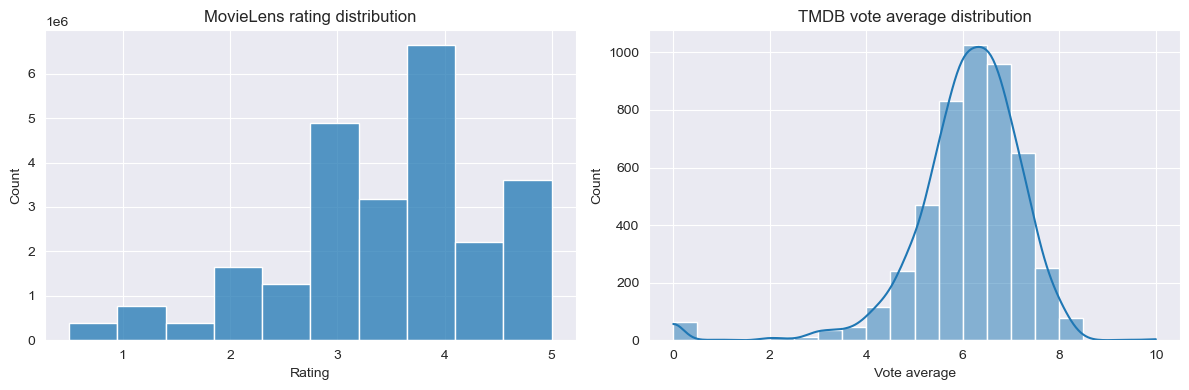

In [47]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(ratings['rating'], bins=10, kde=False)
plt.title('MovieLens rating distribution')
plt.xlabel('Rating')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.histplot(movies['vote_average'], bins=20, kde=True)
plt.title('TMDB vote average distribution')
plt.xlabel('Vote average')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

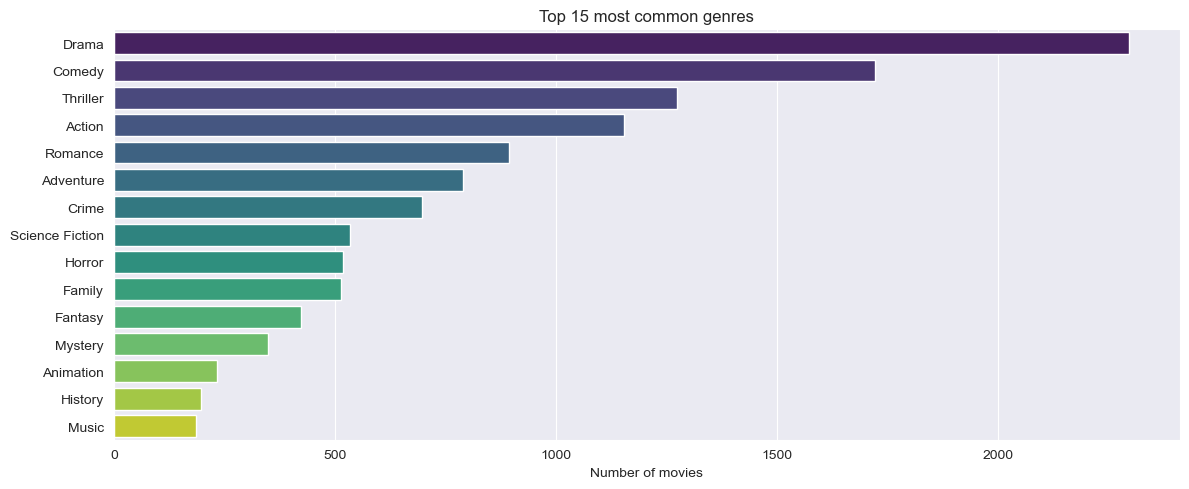

In [57]:
from collections import Counter

all_genres = [genre for sublist in movies['genres'] for genre in sublist]
genre_counts = Counter(all_genres).most_common(15)
genres, counts = zip(*genre_counts)

plt.figure(figsize=(12, 5))
sns.barplot(x=list(counts), y=list(genres), hue=list(genres), palette='viridis', legend=False)
plt.title('Top 15 most common genres')
plt.xlabel('Number of movies')
plt.tight_layout()
plt.show()

Ratings per user stats:
count    162541.000000
mean        153.807932
std         268.047590
min          20.000000
25%          36.000000
50%          71.000000
75%         162.000000
max       32202.000000
Name: rating, dtype: float64


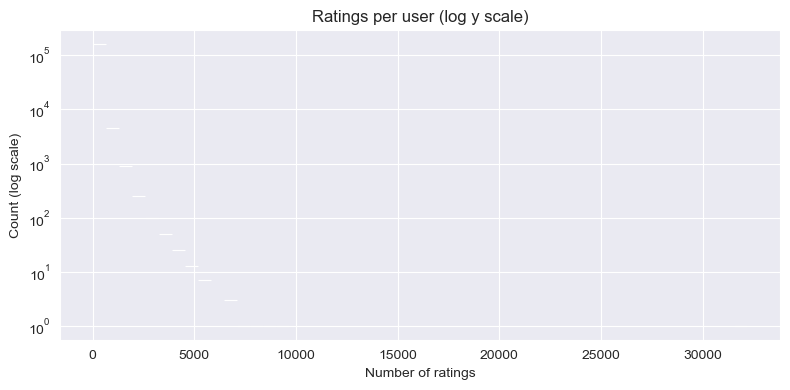

In [59]:
ratings_per_user = ratings.groupby('userId')['rating'].count()

print("Ratings per user stats:")
print(ratings_per_user.describe())

plt.figure(figsize=(8, 4))
sns.histplot(ratings_per_user, bins=50, log_scale=(False, True))
plt.title('Ratings per user (log y scale)')
plt.xlabel('Number of ratings')
plt.ylabel('Count (log scale)')
plt.tight_layout()
plt.show()

In [61]:
# save the cleaned TMDB + credits merged dataframe
movies.to_csv('../data/processed/movies_cleaned.csv', index=False)

# save the matched movies (those with both TMDB and MovieLens data)
matched.to_csv('../data/processed/movies_matched.csv', index=False)

# save links (already cleaned)
links.to_csv('../data/processed/links_cleaned.csv', index=False)

print("All files saved to data/processed/")
print(f"movies_cleaned: {movies.shape}")
print(f"movies_matched: {matched.shape}")
print(f"links_cleaned: {links.shape}")

All files saved to data/processed/
movies_cleaned: (4800, 11)
movies_matched: (4601, 14)
links_cleaned: (62316, 3)


PHASE 2 - CONTENT BASED FILTERING, ML MODEL

